# EEG Pipeline Walkthrough
## From raw time series → windows → feature vectors → horizon labels

This notebook traces every transformation step in the MRCP detection pipeline:

| Step | Input | Output | Function |
|---|---|---|---|
| 0 | Raw CSV | Filtered EEG `(N, C)` | `load_trial` |
| 1 | Button signal `(N,)` | Horizon labels `(N,)` | `make_horizon_labels` |
| 2 | EEG `(N, C)` + labels `(N,)` | Windows `(M, T, C)` + window labels `(M,)` | `build_windows` |
| 3 | One window `(T, C)` | Feature vector `(144,)` | `temporal_features` + `freq_features` |
| 4 | All windows `(M, T, C)` | Feature matrix `(M, 144)` | `features_for_T` |

## 0 · Imports & Config

In [11]:
import warnings
warnings.filterwarnings('ignore')

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy.signal import welch

sys.path.insert(0, '..')
from src.preprocessing import load_trial, make_horizon_labels, build_windows

DARK, CARD, EDGE = '#0a0e17', '#111827', '#1f2937'
TEAL, CORAL, GOLD, WHITE = '#00e5cc', '#ff4f5e', '#ffc947', '#f0f4ff'
LIME, PURPLE = '#a8ff3e', '#c084fc'

plt.rcParams.update({
    'figure.facecolor': DARK, 'axes.facecolor': CARD,
    'axes.edgecolor': EDGE, 'axes.labelcolor': WHITE,
    'xtick.color': WHITE, 'ytick.color': WHITE,
    'text.color': WHITE, 'grid.color': EDGE,
})

SUBJECT    = 9
TRIAL      = 2          # single trial for all walkthrough plots
TACHE      = 'spt'
DATA_PATH  = f'../data/subject{SUBJECT}/'
FS, DECIM  = 250, 4
FS_EFF     = FS // DECIM   # 62 Hz after decimation
LP, HP     = 0.5, 8.0
HORIZON_MS = 300
HORIZON    = int(HORIZON_MS / 1000 * FS_EFF)  # samples
T          = int(1.0 * FS_EFF)                 # window length ~ 1 s (like T_OPT)

print(f'FS_EFF = {FS_EFF} Hz')
print(f'HORIZON = {HORIZON} samples = {HORIZON/FS_EFF*1000:.0f} ms')
print(f'T = {T} samples = {T/FS_EFF*1000:.0f} ms')

FS_EFF = 62 Hz
HORIZON = 18 samples = 290 ms
T = 62 samples = 1000 ms


## 1 · Raw EEG after filtering

`load_trial` reads the CSV, applies:
- **Band-pass filter**: 0.5 – 8 Hz (keeps MRCP band, removes drift and high-freq noise)
- **Decimation** ÷4 (250 Hz → 62 Hz)
- **Common Average Reference (CAR)**: subtracts mean across channels per sample
- **Trial z-score**: each channel normalised to zero mean, unit variance

Trial 2: 3891 samples (62.8 s)  |  16 channels  |  23 presses


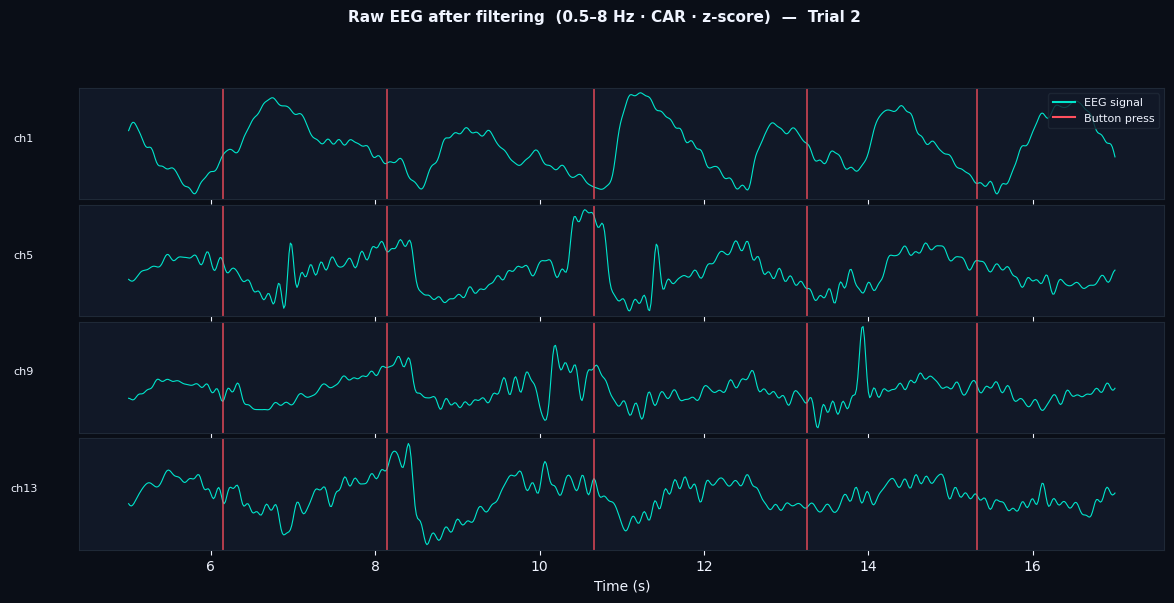

In [12]:
df, EEG_COLS = load_trial(SUBJECT, TACHE, TRIAL, DATA_PATH,
                          lp=LP, hp=HP, decimate=DECIM, car=True, trial_zscore=True)
N_CH = len(EEG_COLS)

eeg   = df[EEG_COLS].values.astype(np.float32)   # (N, C)
press = df['button'].values.astype(np.int8)        # 1 at press onset, else 0
N     = len(eeg)
t_sec = np.arange(N) / FS_EFF

# Press onset samples (load_trial already guarantees onset-only pulses)
press_idx = np.where(press > 0)[0]

print(f'Trial {TRIAL}: {N} samples ({N/FS_EFF:.1f} s)  |  {N_CH} channels  |  {len(press_idx)} presses')

# ── Plot a 12-second slice ────────────────────────────────────────────────────
SHOW_CHS = [0, 4, 8, 12]       # subset of channels to display
T0, T1   = 5.0, 17.0           # time window (seconds)
m        = (t_sec >= T0) & (t_sec <= T1)
ts       = t_sec[m]

fig, axes = plt.subplots(len(SHOW_CHS), 1, figsize=(14, 6), sharex=True,
                          gridspec_kw=dict(hspace=0.05))
fig.suptitle(f'Raw EEG after filtering  (0.5–8 Hz · CAR · z-score)  —  Trial {TRIAL}',
             fontsize=11, fontweight='bold', y=1.01)

for ax, ch in zip(axes, SHOW_CHS):
    ax.plot(ts, eeg[m, ch], color=TEAL, lw=0.8)
    for ps in press_idx:
        ps_t = ps / FS_EFF
        if T0 <= ps_t <= T1:
            ax.axvline(ps_t, color=CORAL, lw=1.2, alpha=0.8)
    ax.set_ylabel(EEG_COLS[ch], color=WHITE, fontsize=8, rotation=0, labelpad=40)
    ax.set_yticks([])

axes[-1].set_xlabel('Time (s)')

legend_handles = [
    plt.Line2D([0],[0], color=TEAL,  lw=1.5, label='EEG signal'),
    plt.Line2D([0],[0], color=CORAL, lw=1.5, label='Button press'),
]
axes[0].legend(handles=legend_handles, facecolor=CARD, labelcolor=WHITE,
               edgecolor=EDGE, loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

## 2 · Horizon Labels

`make_horizon_labels(press, HORIZON)` converts the momentary press signal into an **anticipatory label**:

$$y_h[i] = 1 \quad \text{if} \quad \sum_{k=i}^{i+H-1} \text{press}[k] > 0$$

In other words: sample $i$ is **positive** if a button press will happen **within the next $H$ samples** ($H$ = `HORIZON`).

This gives the model a target it can anticipate — rather than a single spike at the press moment.

Positive samples: 414 / 3,891 (10.6%)
Horizon = 18 samples = 290 ms look-ahead


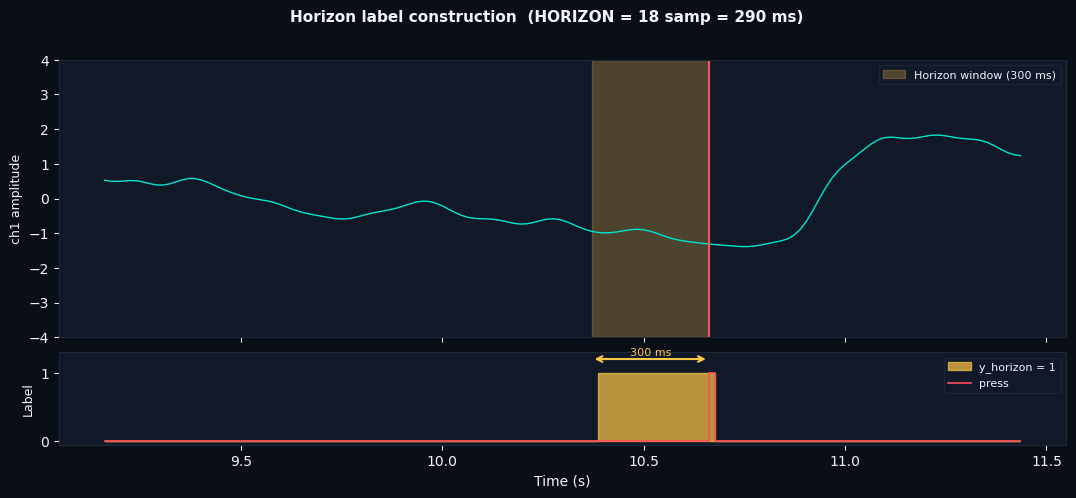

In [3]:
y_horizon = make_horizon_labels(press, HORIZON)   # (N,)

n_pos = y_horizon.sum()
print(f'Positive samples: {n_pos:,} / {N:,} ({n_pos/N*100:.1f}%)')
print(f'Horizon = {HORIZON} samples = {HORIZON/FS_EFF*1000:.0f} ms look-ahead')

# ── Zoom onto 3 consecutive press events ─────────────────────────────────────
p0 = press_idx[3]                                  # anchor on 4th press
ZS, ZE = max(0, p0 - int(1.5*FS_EFF)), min(N, p0 + int(0.8*FS_EFF))
ts_z  = t_sec[ZS:ZE]
ch    = 0                                          # show one channel

fig, (ax_eeg, ax_lbl) = plt.subplots(2, 1, figsize=(13, 5), sharex=True,
                                      gridspec_kw=dict(hspace=0.08, height_ratios=[3,1]))
fig.suptitle(f'Horizon label construction  (HORIZON = {HORIZON} samp = {HORIZON/FS_EFF*1000:.0f} ms)',
             fontsize=11, fontweight='bold')

# EEG trace
ax_eeg.plot(ts_z, eeg[ZS:ZE, ch], color=TEAL, lw=1.0)
ax_eeg.set_ylabel(f'{EEG_COLS[ch]} amplitude', fontsize=9)

# Shade the HORIZON window before each press
for ps in press_idx:
    ps_t = ps / FS_EFF
    start_t = (ps - HORIZON) / FS_EFF
    if ps_t < ts_z[0] or start_t > ts_z[-1]:
        continue
    ax_eeg.axvspan(max(start_t, ts_z[0]), ps_t, color=GOLD, alpha=0.25,
                   label=f'Horizon window ({HORIZON_MS} ms)')
    ax_eeg.axvline(ps_t, color=CORAL, lw=1.5)

ax_eeg.set_ylim(-4, 4)

# Horizon label signal
ax_lbl.fill_between(ts_z, y_horizon[ZS:ZE], step='post',
                    color=GOLD, alpha=0.7, label='y_horizon = 1')
ax_lbl.step(ts_z, press[ZS:ZE], color=CORAL, lw=1.2,
            where='post', label='press')
ax_lbl.set_ylabel('Label', fontsize=9)
ax_lbl.set_xlabel('Time (s)')
ax_lbl.set_ylim(-0.05, 1.3)
ax_lbl.set_yticks([0, 1])

# Annotations on first visible press
for ps in press_idx:
    ps_t = ps / FS_EFF
    if ts_z[0] < ps_t < ts_z[-1]:
        h_start = (ps - HORIZON) / FS_EFF
        ax_lbl.annotate('', xy=(ps_t, 1.2), xytext=(h_start, 1.2),
                        arrowprops=dict(arrowstyle='<->', color=GOLD, lw=1.5))
        ax_lbl.text((ps_t + h_start)/2, 1.25, f'{HORIZON_MS} ms',
                    color=GOLD, ha='center', fontsize=8)
        break

# Deduplicate legend handles
for ax in (ax_eeg, ax_lbl):
    handles, labels = ax.get_legend_handles_labels()
    seen = {}; h, l = [], []
    for hi, li in zip(handles, labels):
        if li not in seen:
            seen[li] = True; h.append(hi); l.append(li)
    ax.legend(h, l, facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)

plt.tight_layout()
plt.show()

## 3 · Sliding Windows

`build_windows(X, y_h, T)` creates a **causal** sliding window dataset:

- **Window $i$** covers EEG samples $[i-T,\; i)$ → shape `(T, C)`
- **Label for window $i$** is `y_h[i]` — the horizon label at the *end* of the window

This is causal: at inference time, sample $i$ is the most recent sample; the model sees the past $T$ samples and predicts whether a press will happen within the next `HORIZON` samples.

The first valid window starts at $i = T$ (the first time we have a full $T$-sample history).

Windows: 3,829  (one per sample, starting at i=62)
X_win shape : (3829, 62, 16)   — (windows, time_steps, channels)
y_win shape : (3829,)
Positive windows: 414 (10.8%)


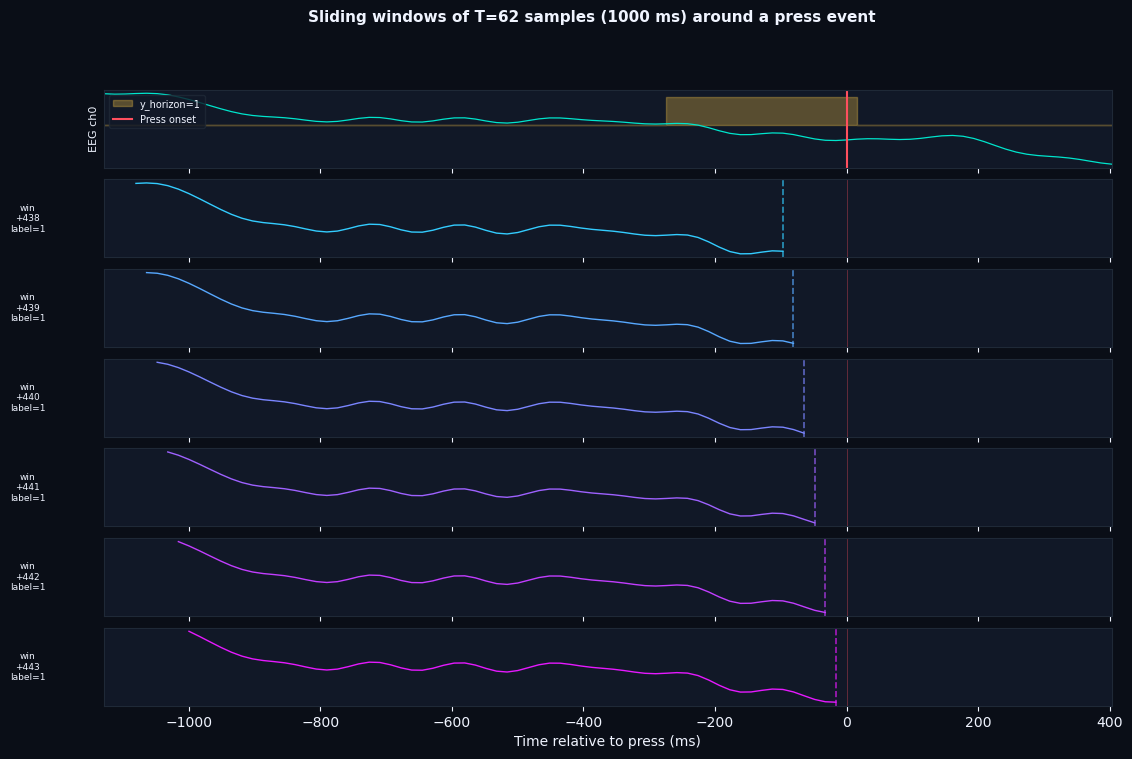

Each window ends at a different sample; label = y_horizon at the window's end sample.
Windows ending ≤18 samples before a press are labelled 1.


In [6]:
X_win_flat, y_win = build_windows(eeg, y_horizon, T, per_window_norm=False)
# Reshape to 3D for cleaner indexing
X_win = X_win_flat.reshape(-1, T, N_CH)    # (M, T, C)
M = len(y_win)

print(f'Windows: {M:,}  (one per sample, starting at i={T})')
print(f'X_win shape : {X_win.shape}   — (windows, time_steps, channels)')
print(f'y_win shape : {y_win.shape}')
print(f'Positive windows: {y_win.sum():,} ({y_win.mean()*100:.1f}%)')

# ── Diagram: window timeline ──────────────────────────────────────────────────
# Show windows around one press event
ps_anchor = press_idx[2]
w_anchor  = ps_anchor - T          # window index whose end = press onset
WIN_RANGE = 6                      # number of windows to illustrate

fig, axes = plt.subplots(WIN_RANGE + 1, 1, figsize=(13, 8), sharex=True,
                          gridspec_kw=dict(hspace=0.15))
fig.suptitle(f'Sliding windows of T={T} samples ({T/FS_EFF*1000:.0f} ms) around a press event',
             fontsize=11, fontweight='bold')

# Global time axis centred on press
REL_START = -(T + WIN_RANGE + 2)
REL_END   = WIN_RANGE + HORIZON + 2
t_rel_all = np.arange(REL_START, REL_END) / FS_EFF * 1000  # ms

# Top panel: EEG + horizon label in global time
ax_top = axes[0]
g0 = ps_anchor + REL_START
g1 = ps_anchor + REL_END
slice_eeg = eeg[max(0,g0):min(N,g1), 0]
slice_lbl = y_horizon[max(0,g0):min(N,g1)]
t_slice   = (np.arange(max(0,g0), min(N,g1)) - ps_anchor) / FS_EFF * 1000

ax_top.fill_between(t_slice, slice_lbl.astype(float), step='post',
                    color=GOLD, alpha=0.3, label='y_horizon=1')
ax_top.plot(t_slice, slice_eeg, color=TEAL, lw=0.9)
ax_top.axvline(0, color=CORAL, lw=1.5, label='Press onset')
ax_top.set_ylabel('EEG ch0', fontsize=8)
ax_top.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=7, loc='upper left')
ax_top.set_yticks([])

# Per-window panels
COLORS = plt.cm.cool(np.linspace(0.2, 0.9, WIN_RANGE))
for k, ax in enumerate(axes[1:]):
    win_i   = w_anchor - WIN_RANGE + k + 1   # window index
    g_end   = ps_anchor - WIN_RANGE + k + 1  # global sample at window end
    g_start = g_end - T

    t_win_ms = (np.arange(g_start, g_end) - ps_anchor) / FS_EFF * 1000
    clr = COLORS[k]

    if 0 <= win_i < M:
        ax.plot(t_win_ms, X_win[win_i, :, 0], color=clr, lw=1.0)
    ax.axvline(t_win_ms[-1], color=clr, lw=1.2, ls='--', alpha=0.7)

    lbl = int(y_win[win_i]) if 0 <= win_i < M else '?'
    rel_ms = t_win_ms[-1]
    ax.set_ylabel(f'win\n{win_i:+d}\nlabel={lbl}', fontsize=6.5,
                  rotation=0, labelpad=55, va='center')
    ax.set_yticks([])

axes[-1].set_xlabel('Time relative to press (ms)')
for ax in axes:
    ax.axvline(0, color=CORAL, lw=0.6, alpha=0.4)
    ax.set_xlim(t_rel_all[0], t_rel_all[-1])

plt.tight_layout()
plt.show()

print('Each window ends at a different sample; label = y_horizon at the window\'s end sample.')
print(f'Windows ending ≤{HORIZON} samples before a press are labelled 1.')

## 4 · Feature Extraction from a Single Window

Each `(T, C)` window → **144-dimensional feature vector**:

| Family | Features | Per channel | Total |
|---|---|---|---|
| Temporal | mean, std, slope, min, argmin, RMS | 6 | 96 |
| Frequency | delta power (0.5–4 Hz), theta power (4–8 Hz), spectral entropy | 3 | 48 |

We'll visualise both families on a single positive window (a window labelled 1, close to a press).

Window index: 1322  |  label: 1  |  shape: (62, 16)


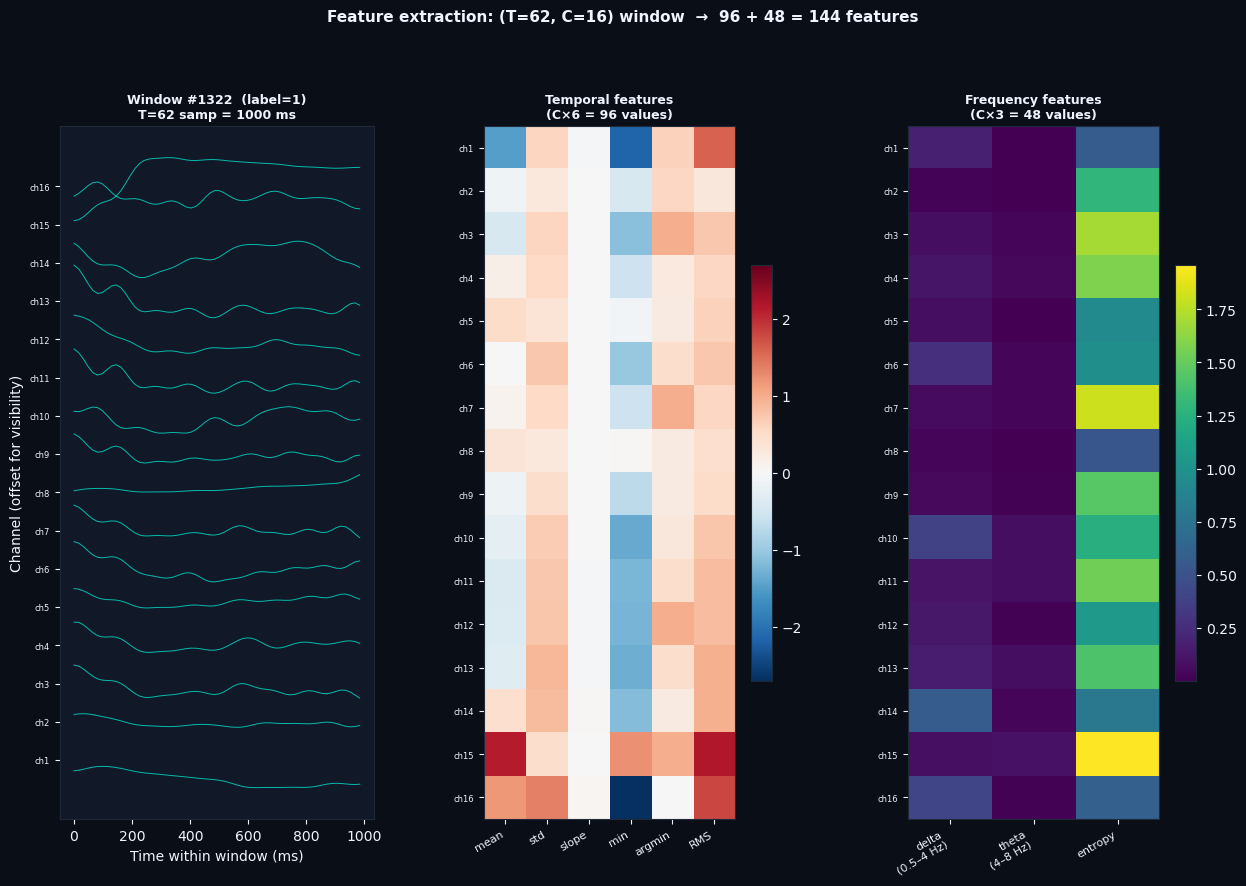


Full feature vector length: 144


In [7]:
# ── Feature functions (same as in the main notebook) ─────────────────────────
def temporal_features(X3d):
    """(N, T, C) -> (N, C*6)"""
    N, T, C = X3d.shape
    X64  = X3d.astype(np.float64)
    t_c  = np.arange(T, dtype=np.float64) - (T - 1) / 2.0
    t_var = (t_c ** 2).sum() + 1e-12
    mean_  = X64.mean(axis=1)
    std_   = X64.std(axis=1)
    slope_ = (X64 * t_c[None, :, None]).sum(axis=1) / t_var
    min_   = X64.min(axis=1)
    argm_  = X64.argmin(axis=1) / T
    rms_   = np.sqrt((X64 ** 2).mean(axis=1))
    return np.stack([mean_, std_, slope_, min_, argm_, rms_],
                    axis=2).reshape(N, C * 6).astype(np.float32)

def freq_features(X3d, fs, batch=2000):
    """(N, T, C) -> (N, C*3)"""
    N, T, C = X3d.shape
    nperseg = min(T, 64)
    out = np.zeros((N, C * 3), dtype=np.float32)
    for s in range(0, N, batch):
        xb = X3d[s:s+batch].transpose(0, 2, 1)
        f, p = welch(xb, fs=fs, nperseg=nperseg, axis=-1)
        df_ = f[1] - f[0]
        dp = p[:, :, (f >= 0.5) & (f <= 4.0)].sum(axis=-1) * df_
        tp = p[:, :, (f >= 4.0) & (f <= 8.0)].sum(axis=-1) * df_
        ma = f > 0
        pn = p[:, :, ma] / (p[:, :, ma].sum(-1, keepdims=True) + 1e-12)
        se = -(pn * np.log(pn + 1e-12)).sum(axis=-1)
        out[s:s+batch, 0::3] = dp
        out[s:s+batch, 1::3] = tp
        out[s:s+batch, 2::3] = se
    return out

# ── Pick one positive window close to a press ─────────────────────────────────
pos_idx = np.where(y_win == 1)[0]
win_idx = pos_idx[len(pos_idx) // 3]       # pick one in the middle of positives
w       = X_win[win_idx]                    # (T, C)
t_w     = np.arange(T) / FS_EFF * 1000     # ms within the window (0 … T/FS_EFF s)

print(f'Window index: {win_idx}  |  label: {y_win[win_idx]}  |  shape: {w.shape}')

# Compute features for this window
w3d = w[np.newaxis]                        # (1, T, C)
t_feat = temporal_features(w3d)[0]         # (C*6,)
f_feat = freq_features(w3d, FS_EFF)[0]     # (C*3,)

t_feat_2d = t_feat.reshape(N_CH, 6)        # (C, 6)
f_feat_2d = f_feat.reshape(N_CH, 3)        # (C, 3)

TEMP_NAMES = ['mean', 'std', 'slope', 'min', 'argmin', 'RMS']
FREQ_NAMES = ['delta\n(0.5–4 Hz)', 'theta\n(4–8 Hz)', 'entropy']

# ── Figure: window + feature heatmaps ────────────────────────────────────────
fig = plt.figure(figsize=(15, 9))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

# Left: raw window (all channels)
ax_win = fig.add_subplot(gs[:, 0])
offset = 3.0
for ch in range(N_CH):
    ax_win.plot(t_w, w[:, ch] + ch * offset, color=TEAL, lw=0.7, alpha=0.8)
ax_win.set_xlabel('Time within window (ms)')
ax_win.set_ylabel('Channel (offset for visibility)')
ax_win.set_title(f'Window #{win_idx}  (label={y_win[win_idx]})\nT={T} samp = {T/FS_EFF*1000:.0f} ms',
                 fontsize=9, fontweight='bold')
ax_win.set_yticks(np.arange(N_CH) * offset)
ax_win.set_yticklabels(EEG_COLS, fontsize=6)

# Middle: temporal features heatmap
ax_tf = fig.add_subplot(gs[:, 1])
im_t  = ax_tf.imshow(t_feat_2d, aspect='auto', cmap='RdBu_r',
                     vmin=-np.abs(t_feat_2d).max(), vmax=np.abs(t_feat_2d).max())
ax_tf.set_xticks(range(6))
ax_tf.set_xticklabels(TEMP_NAMES, fontsize=8, rotation=30, ha='right')
ax_tf.set_yticks(range(N_CH))
ax_tf.set_yticklabels(EEG_COLS, fontsize=6)
ax_tf.set_title(f'Temporal features\n(C×6 = {N_CH*6} values)', fontsize=9, fontweight='bold')
plt.colorbar(im_t, ax=ax_tf, shrink=0.6)

# Right: frequency features heatmap
ax_ff = fig.add_subplot(gs[:, 2])
im_f  = ax_ff.imshow(f_feat_2d, aspect='auto', cmap='viridis')
ax_ff.set_xticks(range(3))
ax_ff.set_xticklabels(FREQ_NAMES, fontsize=8, rotation=30, ha='right')
ax_ff.set_yticks(range(N_CH))
ax_ff.set_yticklabels(EEG_COLS, fontsize=6)
ax_ff.set_title(f'Frequency features\n(C×3 = {N_CH*3} values)', fontsize=9, fontweight='bold')
plt.colorbar(im_f, ax=ax_ff, shrink=0.6)

fig.suptitle(f'Feature extraction: (T={T}, C={N_CH}) window  →  {N_CH*6} + {N_CH*3} = {N_CH*9} features',
             fontsize=11, fontweight='bold', y=1.01)
plt.savefig('report/walkthrough_features.png', dpi=110, bbox_inches='tight', facecolor=DARK)
plt.show()

print(f'\nFull feature vector length: {len(np.concatenate([t_feat, f_feat]))}')

## 5 · Power Spectral Density — one window

The Welch PSD is computed on each channel of the window. Delta (0.5–4 Hz) and theta (4–8 Hz) band powers are integrated from the PSD; spectral entropy is the normalised entropy of the PSD.

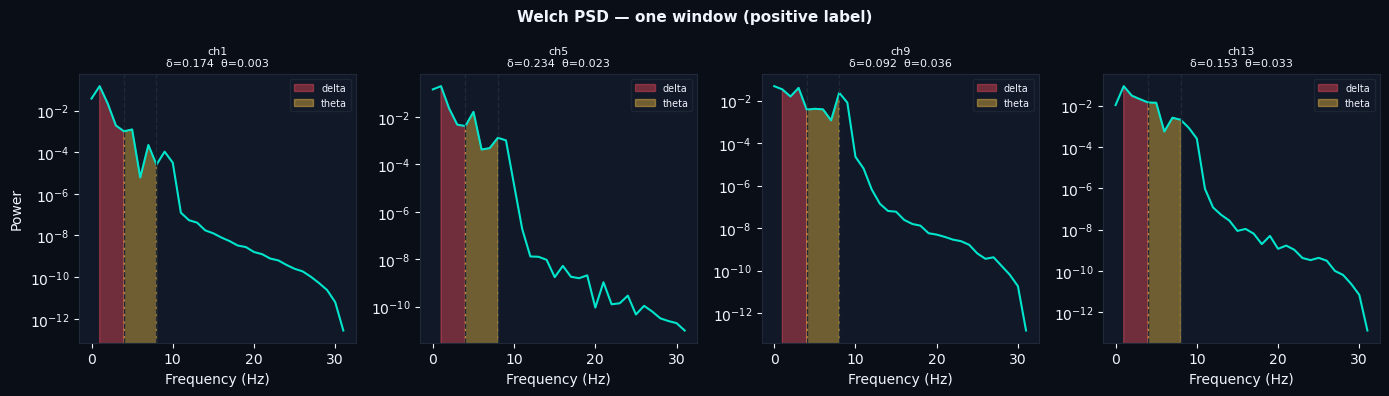

In [6]:
from scipy.signal import welch as scipy_welch

nperseg = min(T, 64)
SHOW_CHS_PSD = [0, 4, 8, 12]

fig, axes = plt.subplots(1, len(SHOW_CHS_PSD), figsize=(14, 4), sharey=False)
fig.suptitle('Welch PSD — one window (positive label)', fontsize=11, fontweight='bold')

for ax, ch in zip(axes, SHOW_CHS_PSD):
    f, psd = scipy_welch(w[:, ch], fs=FS_EFF, nperseg=nperseg)
    ax.semilogy(f, psd, color=TEAL, lw=1.5)

    # Shade bands
    m_d = (f >= 0.5) & (f <= 4.0)
    m_t = (f >= 4.0) & (f <= 8.0)
    ax.fill_between(f[m_d], psd[m_d], alpha=0.4, color=CORAL, label='delta')
    ax.fill_between(f[m_t], psd[m_t], alpha=0.4, color=GOLD,  label='theta')

    delta_p = float(psd[m_d].sum() * (f[1]-f[0]))
    theta_p = float(psd[m_t].sum() * (f[1]-f[0]))
    ax.set_title(f'{EEG_COLS[ch]}\nδ={delta_p:.3f}  θ={theta_p:.3f}', fontsize=8)
    ax.set_xlabel('Frequency (Hz)')
    ax.axvline(4.0, color=EDGE, lw=1, ls='--')
    ax.axvline(8.0, color=EDGE, lw=1, ls='--')
    ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=7)

axes[0].set_ylabel('Power')
plt.tight_layout()
plt.show()

## 6 · Full Feature Matrix

After computing features for every window, we get the matrix fed to LightGBM:

```
X_feat  :  (M, 144)   M ≈ 3 000 – 4 000 windows per trial
y_win   :  (M,)       binary horizon labels
```

The heatmap below shows the first 500 windows sorted by label — positive windows on top.

X_feat shape : (3829, 144)   (windows × features)
y_win  shape : (3829,)
Positive     : 414 (10.8%)
Negative     : 3,415 (89.2%)


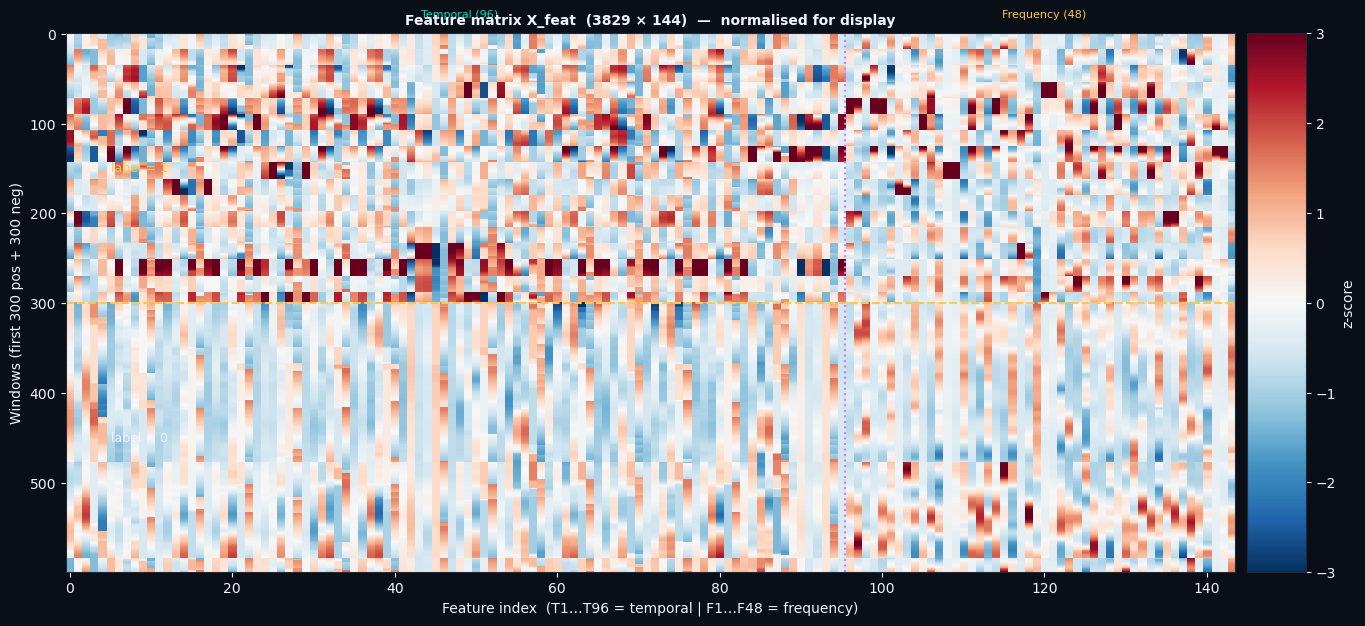

In [8]:
# Build full feature matrix for this trial
X_feat = np.concatenate([temporal_features(X_win), freq_features(X_win, FS_EFF)], axis=1)

print(f'X_feat shape : {X_feat.shape}   (windows × features)')
print(f'y_win  shape : {y_win.shape}')
print(f'Positive     : {y_win.sum():,} ({y_win.mean()*100:.1f}%)')
print(f'Negative     : {(1-y_win).sum():,} ({(1-y_win).mean()*100:.1f}%)')

# Sort and subsample for visualisation
SHOW = 600
pos_rows = np.where(y_win == 1)[0][:SHOW//2]
neg_rows = np.where(y_win == 0)[0][:SHOW//2]
sel      = np.concatenate([pos_rows, neg_rows])
X_show   = X_feat[sel]
y_show   = y_win[sel]

# Standardise each feature column for display
mu  = X_show.mean(axis=0)
sig = X_show.std(axis=0) + 1e-8
X_norm = (X_show - mu) / sig
X_norm = np.clip(X_norm, -3, 3)

FEAT_NAMES_SHORT = (
    [f'T{i+1}' for i in range(N_CH * 6)] +
    [f'F{i+1}' for i in range(N_CH * 3)]
)

fig, (ax_mat, ax_lbl) = plt.subplots(1, 2, figsize=(16, 7),
                                      gridspec_kw=dict(width_ratios=[20, 1], wspace=0.02))

im = ax_mat.imshow(X_norm, aspect='auto', cmap='RdBu_r', vmin=-3, vmax=3,
                   interpolation='nearest')
ax_mat.axhline(len(pos_rows) - 0.5, color=GOLD, lw=1.5, ls='--')
ax_mat.text(5, len(pos_rows) // 2, 'label = 1', color=GOLD, fontsize=9, va='center')
ax_mat.text(5, len(pos_rows) + len(neg_rows)//2, 'label = 0', color=WHITE, fontsize=9, va='center')

# Mark feature family boundaries
ax_mat.axvline(N_CH * 6 - 0.5, color=PURPLE, lw=1.5, ls=':')
ax_mat.text(N_CH * 3, -18, 'Temporal (96)', color=TEAL, ha='center', fontsize=8)
ax_mat.text(N_CH * 6 + N_CH * 1.5, -18, 'Frequency (48)', color=GOLD, ha='center', fontsize=8)

ax_mat.set_xlabel('Feature index  (T1…T96 = temporal | F1…F48 = frequency)')
ax_mat.set_ylabel(f'Windows (first {SHOW//2} pos + {SHOW//2} neg)')
ax_mat.set_title(f'Feature matrix X_feat  ({X_feat.shape[0]} × {X_feat.shape[1]})  —  normalised for display',
                 fontsize=10, fontweight='bold')

plt.colorbar(im, cax=ax_lbl, label='z-score')

plt.savefig('report/walkthrough_matrix.png', dpi=110, bbox_inches='tight', facecolor=DARK)
plt.show()

## 7 · Low-Dimensional Embeddings of the Feature Space

PCA and t-SNE project the 144-dimensional feature vectors down to 2D, revealing how separable the classes are.

- **PCA** shows any *linear* separation; the explained variance tells you how much information survives the projection.
- **t-SNE** reveals *local cluster structure* — tight clusters of pre-press windows indicate consistent MRCP morphology across events.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ── Balanced subsample ────────────────────────────────────────────────────────
rng     = np.random.default_rng(42)
MAX_PTS = 1500
pos_e   = np.where(y_win == 1)[0]
neg_e   = np.where(y_win == 0)[0]
n_each  = min(MAX_PTS // 2, len(pos_e), len(neg_e))
sel     = np.sort(np.concatenate([
    rng.choice(pos_e, n_each, replace=False),
    rng.choice(neg_e, n_each, replace=False),
]))
X_e = X_feat[sel]
y_e = y_win[sel]

X_es = StandardScaler().fit_transform(X_e)

# PCA
pca     = PCA(n_components=2, random_state=42)
Z_pca   = pca.fit_transform(X_es)
var_exp = pca.explained_variance_ratio_ * 100

# t-SNE — initialise from PCA-50 for speed and reproducibility
n_comp50 = min(50, X_es.shape[1])
X_p50    = PCA(n_components=n_comp50, random_state=42).fit_transform(X_es)
Z_tsne   = TSNE(n_components=2, perplexity=40, random_state=42,
                n_iter=1000, init='pca', learning_rate='auto').fit_transform(X_p50)

print(f'PCA: PC1={var_exp[0]:.1f}%  PC2={var_exp[1]:.1f}%  '
      f'cumulative={var_exp.sum():.1f}%  |  {n_each} pos + {n_each} neg')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    f'Embeddings of X_feat  ({n_each} pos + {n_each} neg  ·  {X_e.shape[1]} features)',
    fontsize=11, fontweight='bold',
)

titles = [
    f'PCA  (PC1 {var_exp[0]:.1f}%  +  PC2 {var_exp[1]:.1f}%)',
    't-SNE  (perplexity=40)',
]

for ax, Z, title in zip(axes, [Z_pca, Z_tsne], titles):
    ax.scatter(Z[y_e == 0, 0], Z[y_e == 0, 1],
               c=TEAL,  s=10, alpha=0.40, linewidths=0, label='label = 0  (rest)')
    ax.scatter(Z[y_e == 1, 0], Z[y_e == 1, 1],
               c=CORAL, s=12, alpha=0.65, linewidths=0, label='label = 1  (pre-press)')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Component 1', fontsize=9)
    ax.set_ylabel('Component 2', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8, markerscale=2)

plt.tight_layout()
plt.show()

## 7 · End-to-End Summary

```
CSV file
  │
  ▼  load_trial()   — bandpass 0.5–8 Hz · decimate ÷4 · CAR · z-score
  │
  ├─── eeg  (N, 16)          raw EEG,  N ≈ 4 000 samples @ 62 Hz
  └─── press (N,)             momentary button-press signal
         │
         ▼  make_horizon_labels(press, HORIZON)
         │
         y_horizon (N,)        1 if a press is ≤ 300 ms ahead, else 0
         │
         ▼  build_windows(eeg, y_horizon, T)
         │
         ├─── X_win  (M, T, 16)     M windows of T=63 samples each
         └─── y_win  (M,)           horizon label at the end of each window
                │
                ▼  temporal_features() + freq_features()
                │
                X_feat  (M, 144)    96 temporal + 48 frequency features
                y_win   (M,)        labels → fed to LightGBM
```

In [9]:
print('Pipeline summary')
print('=' * 50)
print(f'  Raw samples      : {N:,}  ({N/FS_EFF:.1f} s @ {FS_EFF} Hz)')
print(f'  Channels         : {N_CH}')
print(f'  Horizon          : {HORIZON} samp = {HORIZON/FS_EFF*1000:.0f} ms')
print(f'  Positive samples : {y_horizon.sum():,} ({y_horizon.mean()*100:.1f}%)')
print(f'  Window length T  : {T} samp = {T/FS_EFF*1000:.0f} ms')
print(f'  Windows (M)      : {M:,}')
print(f'  Positive windows : {y_win.sum():,} ({y_win.mean()*100:.1f}%)')
print(f'  Features / window: {X_feat.shape[1]}  (temporal {N_CH*6} + freq {N_CH*3})')
print('=' * 50)

Pipeline summary
  Raw samples      : 3,891  (62.8 s @ 62 Hz)
  Channels         : 16
  Horizon          : 18 samp = 290 ms
  Positive samples : 414 (10.6%)
  Window length T  : 62 samp = 1000 ms
  Windows (M)      : 3,829
  Positive windows : 414 (10.8%)
  Features / window: 144  (temporal 96 + freq 48)
